# Community Detection on Zachary's Karate Club

## Import Required Libraries

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import sys
sys.path.append('../../../src')

from rice_ml.unsupervised_learning.community_detection import (
    CommunityDetection, 
    LabelPropagation,
    calculate_modularity
)

# Set random seed for reproducibility
np.random.seed(42)

## Load and Explore the Dataset

We'll load Zachary's Karate Club network using NetworkX and explore its basic properties.

In [3]:
# Load Zachary's Karate Club graph
G = nx.karate_club_graph()

# Display basic information
print("=== Zachary's Karate Club Network ===")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Network density: {nx.density(G):.4f}")
print(f"Average clustering coefficient: {nx.average_clustering(G):.4f}")
print(f"Is connected: {nx.is_connected(G)}")

# Get the ground truth communities
print("\n=== Ground Truth ===")
print("The network split into two groups:")
ground_truth = {}
for node in G.nodes():
    # The 'club' attribute indicates which group the member joined
    ground_truth[node] = 0 if G.nodes[node]['club'] == 'Mr. Hi' else 1

group_0 = [node for node, group in ground_truth.items() if group == 0]
group_1 = [node for node, group in ground_truth.items() if group == 1]

print(f"Group 0 (Mr. Hi): {len(group_0)} members")
print(f"Group 1 (Officer): {len(group_1)} members")

=== Zachary's Karate Club Network ===
Number of nodes: 34
Number of edges: 78
Network density: 0.1390
Average clustering coefficient: 0.5706
Is connected: True

=== Ground Truth ===
The network split into two groups:
Group 0 (Mr. Hi): 17 members
Group 1 (Officer): 17 members


## Visualize the Original Network

Let's visualize the network with the ground truth communities.

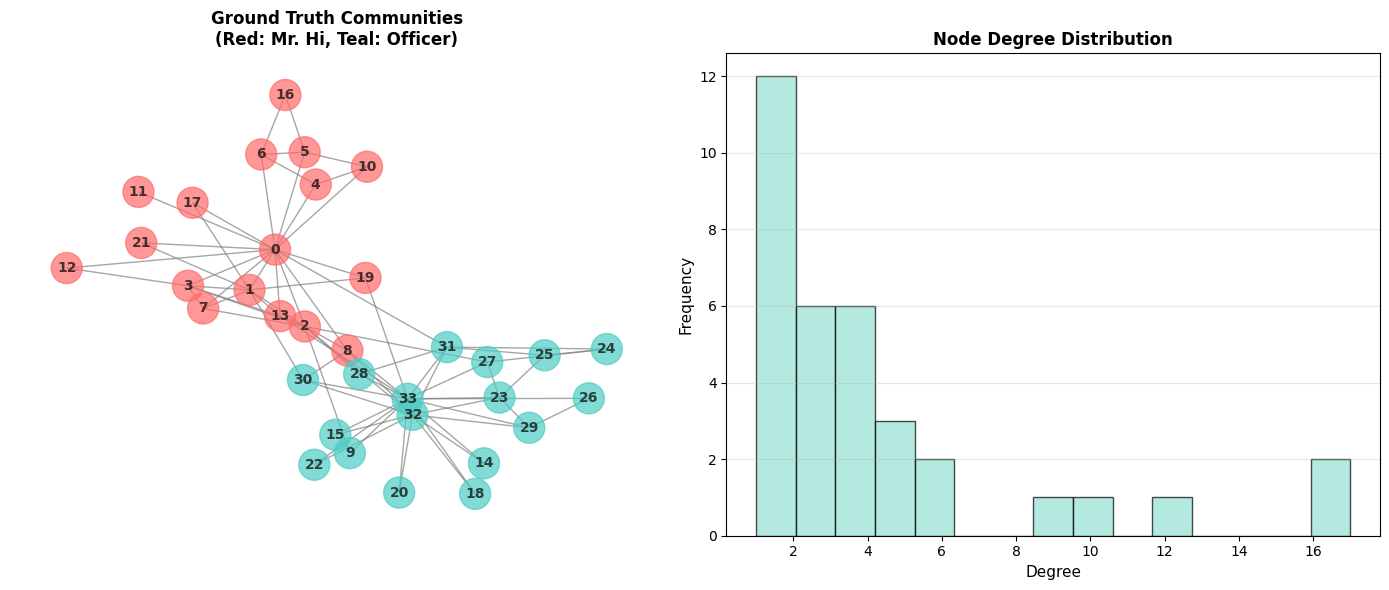

Average degree: 4.59
Max degree: 17 (Node 33)
Min degree: 1


In [4]:
plt.figure(figsize=(14, 6))

# Subplot 1: Ground truth communities
plt.subplot(1, 2, 1)
pos = nx.spring_layout(G, seed=42)
colors = ['#FF6B6B' if ground_truth[node] == 0 else '#4ECDC4' for node in G.nodes()]
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=500, 
        font_size=10, font_weight='bold', edge_color='gray', alpha=0.7)
plt.title("Ground Truth Communities\n(Red: Mr. Hi, Teal: Officer)", fontsize=12, fontweight='bold')

# Subplot 2: Node degree distribution
plt.subplot(1, 2, 2)
degrees = [G.degree(node) for node in G.nodes()]
plt.hist(degrees, bins=15, color='#95E1D3', edgecolor='black', alpha=0.7)
plt.xlabel('Degree', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Node Degree Distribution', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Show some statistics about degree
print(f"Average degree: {np.mean(degrees):.2f}")
print(f"Max degree: {max(degrees)} (Node {degrees.index(max(degrees))})")
print(f"Min degree: {min(degrees)}")

## Data Processing

Convert the NetworkX graph to an adjacency matrix that our algorithm can use.

In [5]:
# Convert the graph to an adjacency matrix
adjacency_matrix = nx.to_numpy_array(G)

print("=== Adjacency Matrix ===")
print(f"Shape: {adjacency_matrix.shape}")
print(f"Data type: {adjacency_matrix.dtype}")
print(f"Is symmetric: {np.allclose(adjacency_matrix, adjacency_matrix.T)}")
print(f"Number of non-zero entries: {np.count_nonzero(adjacency_matrix)}")

# Display a portion of the adjacency matrix
print("\nFirst 10x10 portion of the adjacency matrix:")
print(adjacency_matrix[:10, :10].astype(int))

=== Adjacency Matrix ===
Shape: (34, 34)
Data type: float64
Is symmetric: True
Number of non-zero entries: 156

First 10x10 portion of the adjacency matrix:
[[0 4 5 3 3 3 3 2 2 0]
 [4 0 6 3 0 0 0 4 0 0]
 [5 6 0 3 0 0 0 4 5 1]
 [3 3 3 0 0 0 0 3 0 0]
 [3 0 0 0 0 0 2 0 0 0]
 [3 0 0 0 0 0 5 0 0 0]
 [3 0 0 0 2 5 0 0 0 0]
 [2 4 4 3 0 0 0 0 0 0]
 [2 0 5 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0]]


## Apply Community Detection Algorithms

Now we'll apply our custom implementations of community detection algorithms to the Karate Club network.

### Algorithm 1: Louvain Method

In [6]:
# Apply Louvain method
print("=== Running Louvain Algorithm ===\n")
louvain = CommunityDetection()
louvain.fit(adjacency_matrix, max_iterations=100)

# Get results
louvain_communities = louvain.predict()
louvain_modularity = louvain.get_modularity()
n_communities_louvain = louvain.get_n_communities()

print(f"Number of communities detected: {n_communities_louvain}")
print(f"Final modularity: {louvain_modularity:.4f}")
print(f"Number of iterations: {len(louvain.modularity_history)}")

# Show community assignments
communities_list = louvain.get_communities_as_lists()
for i, community in enumerate(communities_list):
    print(f"\nCommunity {i}: {len(community)} members")
    print(f"Members: {sorted(community)}")

=== Running Louvain Algorithm ===

Number of communities detected: 9
Final modularity: 0.1523
Number of iterations: 4

Community 0: 6 members
Members: [0, 11, 13, 17, 19, 21]

Community 1: 5 members
Members: [1, 2, 3, 7, 12]

Community 2: 2 members
Members: [4, 6]

Community 3: 3 members
Members: [5, 10, 16]

Community 4: 7 members
Members: [8, 9, 15, 18, 22, 26, 32]

Community 5: 5 members
Members: [14, 20, 29, 30, 33]

Community 6: 2 members
Members: [23, 27]

Community 7: 2 members
Members: [24, 31]

Community 8: 2 members
Members: [25, 28]


### Algorithm 2: Label Propagation

Label propagation is a simpler algorithm where each node iteratively adopts the most common label among its neighbors.

In [7]:
# Apply Label Propagation
print("=== Running Label Propagation Algorithm ===\n")
label_prop = LabelPropagation(max_iterations=100)
label_prop.fit(adjacency_matrix)

# Get results
lp_communities = label_prop.predict()
lp_modularity = calculate_modularity(adjacency_matrix, lp_communities)
n_communities_lp = label_prop.get_n_communities()

print(f"Number of communities detected: {n_communities_lp}")
print(f"Modularity: {lp_modularity:.4f}")

# Show community assignments
lp_communities_list = label_prop.get_communities_as_lists()
for i, community in enumerate(lp_communities_list):
    print(f"\nCommunity {i}: {len(community)} members")
    print(f"Members: {sorted(community)}")

=== Running Label Propagation Algorithm ===

Number of communities detected: 2
Modularity: 0.4036

Community 0: 16 members
Members: [0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21]

Community 1: 18 members
Members: [8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


## Visualize Results

Let's visualize the communities detected by both algorithms and compare them with the ground truth.

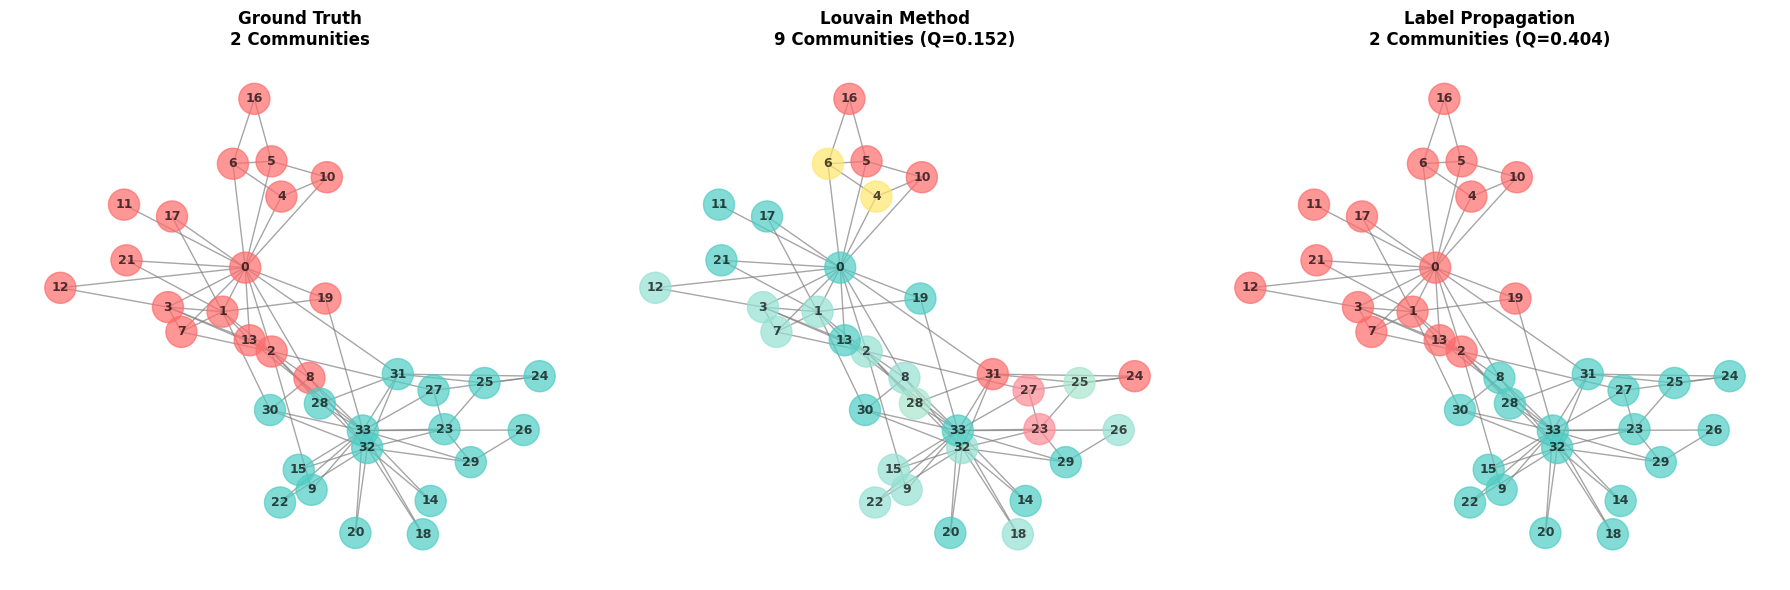

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Color palettes for different numbers of communities
def get_colors(communities, n_communities):
    color_map = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFE66D', '#A8E6CF', '#FF8B94']
    return [color_map[communities[node] % len(color_map)] for node in G.nodes()]

# Plot 1: Ground Truth
ax = axes[0]
plt.sca(ax)
colors_gt = get_colors(ground_truth, 2)
nx.draw(G, pos, node_color=colors_gt, with_labels=True, node_size=500,
        font_size=9, font_weight='bold', edge_color='gray', alpha=0.7, ax=ax)
ax.set_title(f"Ground Truth\n{len(set(ground_truth.values()))} Communities", 
             fontsize=12, fontweight='bold')

# Plot 2: Louvain Method
ax = axes[1]
plt.sca(ax)
colors_louvain = get_colors(louvain_communities, n_communities_louvain)
nx.draw(G, pos, node_color=colors_louvain, with_labels=True, node_size=500,
        font_size=9, font_weight='bold', edge_color='gray', alpha=0.7, ax=ax)
ax.set_title(f"Louvain Method\n{n_communities_louvain} Communities (Q={louvain_modularity:.3f})", 
             fontsize=12, fontweight='bold')

# Plot 3: Label Propagation
ax = axes[2]
plt.sca(ax)
colors_lp = get_colors(lp_communities, n_communities_lp)
nx.draw(G, pos, node_color=colors_lp, with_labels=True, node_size=500,
        font_size=9, font_weight='bold', edge_color='gray', alpha=0.7, ax=ax)
ax.set_title(f"Label Propagation\n{n_communities_lp} Communities (Q={lp_modularity:.3f})", 
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Evaluate and Compare Results

Let's quantitatively evaluate how well our algorithms performed.

In [9]:
# Function to calculate accuracy against ground truth
def calculate_accuracy(predicted, ground_truth):
    """
    Calculate accuracy by trying both possible mappings of predicted communities
    to ground truth communities (since labels are arbitrary).
    """
    n = len(predicted)
    correct_original = sum(1 for node in predicted 
                          if predicted[node] == ground_truth[node])
    
    # Try flipped mapping
    predicted_flipped = {node: 1 - comm for node, comm in predicted.items()}
    correct_flipped = sum(1 for node in predicted_flipped 
                         if predicted_flipped[node] == ground_truth[node])
    
    return max(correct_original, correct_flipped) / n

# Calculate accuracy for both algorithms
louvain_accuracy = calculate_accuracy(louvain_communities, ground_truth)
lp_accuracy = calculate_accuracy(lp_communities, ground_truth)

# Calculate modularity for ground truth
gt_modularity = calculate_modularity(adjacency_matrix, ground_truth)

# Display comparison
print("=== Algorithm Comparison ===\n")
print(f"{'Metric':<25} {'Ground Truth':<15} {'Louvain':<15} {'Label Prop':<15}")
print("-" * 70)
print(f"{'Number of Communities':<25} {len(set(ground_truth.values())):<15} {n_communities_louvain:<15} {n_communities_lp:<15}")
print(f"{'Modularity':<25} {gt_modularity:<15.4f} {louvain_modularity:<15.4f} {lp_modularity:<15.4f}")
print(f"{'Accuracy vs Ground Truth':<25} {'-':<15} {louvain_accuracy:<15.2%} {lp_accuracy:<15.2%}")

# Community size distribution
print("\n=== Community Size Distribution ===\n")
print(f"Ground Truth: {[len(group_0), len(group_1)]}")
print(f"Louvain: {[len(c) for c in communities_list]}")
print(f"Label Propagation: {[len(c) for c in lp_communities_list]}")

=== Algorithm Comparison ===

Metric                    Ground Truth    Louvain         Label Prop     
----------------------------------------------------------------------
Number of Communities     2               9               2              
Modularity                0.3914          0.1523          0.4036         
Accuracy vs Ground Truth  -               17.65%          97.06%         

=== Community Size Distribution ===

Ground Truth: [17, 17]
Louvain: [6, 5, 2, 3, 7, 5, 2, 2, 2]
Label Propagation: [16, 18]


## Modularity Convergence

Let's visualize how the modularity improves during the Louvain algorithm iterations.

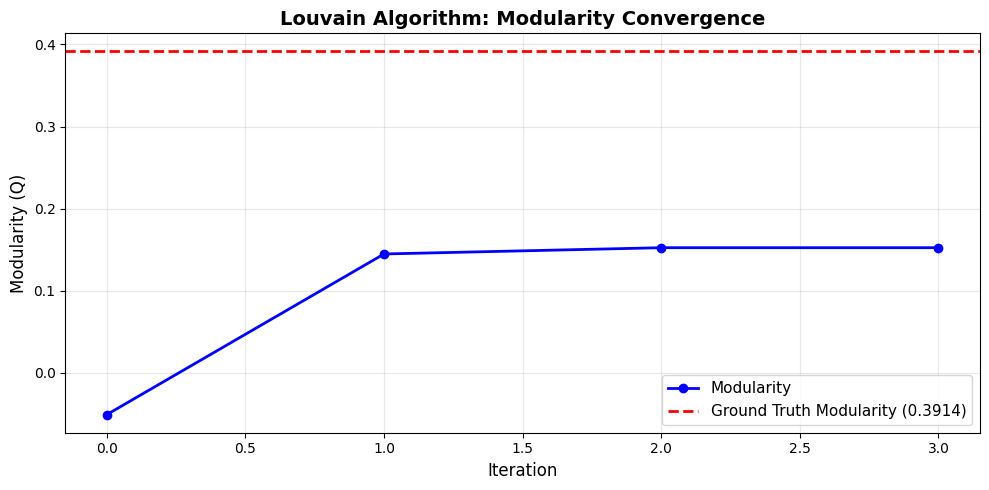

Initial modularity: -0.0511
Final modularity: 0.1523
Improvement: 0.2034


In [10]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(louvain.modularity_history)), louvain.modularity_history, 
         'b-o', linewidth=2, markersize=6, label='Modularity')
plt.axhline(y=gt_modularity, color='r', linestyle='--', linewidth=2, 
            label=f'Ground Truth Modularity ({gt_modularity:.4f})')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Modularity (Q)', fontsize=12)
plt.title('Louvain Algorithm: Modularity Convergence', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Initial modularity: {louvain.modularity_history[0]:.4f}")
print(f"Final modularity: {louvain.modularity_history[-1]:.4f}")
print(f"Improvement: {louvain.modularity_history[-1] - louvain.modularity_history[0]:.4f}")

## Analyze Community Structure

Let's analyze the structural properties of the detected communities.

In [11]:
def analyze_community_structure(G, communities):
    """
    Analyze internal and external connectivity of communities.
    """
    # Count internal and external edges
    internal_edges = 0
    external_edges = 0
    
    for u, v in G.edges():
        if communities[u] == communities[v]:
            internal_edges += 1
        else:
            external_edges += 1
    
    total_edges = G.number_of_edges()
    
    print(f"Total edges: {total_edges}")
    print(f"Internal edges (within communities): {internal_edges} ({internal_edges/total_edges*100:.1f}%)")
    print(f"External edges (between communities): {external_edges} ({external_edges/total_edges*100:.1f}%)")
    
    # Calculate average clustering coefficient within communities
    communities_dict = {}
    for node, comm in communities.items():
        if comm not in communities_dict:
            communities_dict[comm] = []
        communities_dict[comm].append(node)
    
    print(f"\nCommunity-specific metrics:")
    for comm_id, nodes in sorted(communities_dict.items()):
        subgraph = G.subgraph(nodes)
        n_nodes = len(nodes)
        n_edges = subgraph.number_of_edges()
        density = nx.density(subgraph) if n_nodes > 1 else 0
        avg_clustering = nx.average_clustering(subgraph) if n_nodes > 1 else 0
        
        print(f"\nCommunity {comm_id}:")
        print(f"  Nodes: {n_nodes}")
        print(f"  Internal edges: {n_edges}")
        print(f"  Density: {density:.4f}")
        print(f"  Average clustering: {avg_clustering:.4f}")

print("=== Louvain Communities ===")
analyze_community_structure(G, louvain_communities)

print("\n" + "="*60 + "\n")

print("=== Label Propagation Communities ===")
analyze_community_structure(G, lp_communities)

=== Louvain Communities ===
Total edges: 78
Internal edges (within communities): 25 (32.1%)
External edges (between communities): 53 (67.9%)

Community-specific metrics:

Community 0:
  Nodes: 3
  Internal edges: 2
  Density: 0.6667
  Average clustering: 0.0000

Community 1:
  Nodes: 6
  Internal edges: 5
  Density: 0.3333
  Average clustering: 0.0000

Community 2:
  Nodes: 5
  Internal edges: 7
  Density: 0.7000
  Average clustering: 0.7000

Community 3:
  Nodes: 2
  Internal edges: 1
  Density: 1.0000
  Average clustering: 0.0000

Community 4:
  Nodes: 2
  Internal edges: 0
  Density: 0.0000
  Average clustering: 0.0000

Community 5:
  Nodes: 2
  Internal edges: 1
  Density: 1.0000
  Average clustering: 0.0000

Community 6:
  Nodes: 2
  Internal edges: 1
  Density: 1.0000
  Average clustering: 0.0000

Community 7:
  Nodes: 5
  Internal edges: 4
  Density: 0.4000
  Average clustering: 0.0000

Community 8:
  Nodes: 7
  Internal edges: 4
  Density: 0.1905
  Average clustering: 0.0000




## Interpretation 
